# LumenY 6.0 — 02: Big Move Exploratory Analysis

Before training, we need to understand:
1. How often do big moves happen? What's the distribution?
2. Which pairs produce the most big moves?
3. When do big moves occur (session, hour, day)?
4. What do microstructure features look like *before* a big move vs normal conditions?
5. What MFE threshold should we use for the classification target?

**Input:** `features_6/` parquet files (from notebook 01)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR = Path('../backend/data/features_6')

ALL_PAIRS = [
    'EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD'
]

TRAIN_END = '2024-06-30'

# Load all pairs
dfs = []
for pair in ALL_PAIRS:
    df = pd.read_parquet(FEATURES_DIR / f'{pair}_features.parquet')
    dfs.append(df)
    print(f'{pair}: {len(df):,} rows')

df_all = pd.concat(dfs)
del dfs

# Identify column groups
label_cols = ['mfe_long_pips', 'mfe_short_pips', 'trail_long_bars', 'trail_short_bars', 'trail_stop_pips', 'mfe_atr_24']
feature_cols = [c for c in df_all.columns if c not in label_cols + ['pair']]

print(f'\nTotal: {len(df_all):,} rows, {len(feature_cols)} features')
print(f'Date range: {df_all.index.min().date()} to {df_all.index.max().date()}')

EURUSD: 100,675 rows
GBPUSD: 100,269 rows
AUDUSD: 101,011 rows
NZDUSD: 99,663 rows
USDCAD: 100,185 rows
USDCHF: 100,541 rows
USDJPY: 99,773 rows
EURJPY: 101,493 rows
GBPJPY: 101,425 rows
EURGBP: 100,757 rows
EURAUD: 100,929 rows
AUDJPY: 101,994 rows
CADJPY: 102,252 rows
CHFJPY: 100,835 rows
AUDNZD: 106,218 rows

Total: 1,518,020 rows, 112 features
Date range: 2009-09-25 to 2025-12-31


## 1. MFE Distribution — How Often Do Big Moves Happen?

In [2]:
# Best MFE per bar: max(long, short) — the best trade you could have taken
df_valid = df_all.dropna(subset=['mfe_long_pips', 'mfe_short_pips']).copy()
df_valid['mfe_best'] = np.maximum(df_valid['mfe_long_pips'], df_valid['mfe_short_pips'])
df_valid['best_dir'] = np.where(df_valid['mfe_long_pips'] >= df_valid['mfe_short_pips'], 'long', 'short')

print(f'Valid rows: {len(df_valid):,}')
print(f'\nMFE Best (pips) — overall distribution:')
print(df_valid['mfe_best'].describe())

# Threshold analysis
print(f'\n{"Threshold":>12} {"Count":>10} {"% of bars":>10} {"Avg MFE":>10} {"Med Duration":>12}')
print('-' * 60)
for thresh in [10, 20, 30, 40, 50, 60, 80, 100]:
    mask = df_valid['mfe_best'] > thresh
    if mask.sum() == 0:
        continue
    subset = df_valid[mask]
    # Duration = min of long/short trail bars for the winning direction
    dur_long = subset.loc[subset['best_dir'] == 'long', 'trail_long_bars']
    dur_short = subset.loc[subset['best_dir'] == 'short', 'trail_short_bars']
    dur = pd.concat([dur_long, dur_short])
    print(f'{thresh:>10} pips {mask.sum():>10,} {100*mask.mean():>9.1f}% {subset["mfe_best"].mean():>9.1f} {dur.median():>10.0f}h')

Valid rows: 1,471,525

MFE Best (pips) — overall distribution:
count    1.471525e+06
mean     4.415449e+01
std      5.932520e+01
min      0.000000e+00
25%      2.210000e+01
50%      3.330000e+01
75%      5.160000e+01
max      1.013354e+04
Name: mfe_best, dtype: float64

   Threshold      Count  % of bars    Avg MFE Med Duration
------------------------------------------------------------
        10 pips  1,448,197      98.4%      44.7          6h
        20 pips  1,178,652      80.1%      51.3          6h
        30 pips    832,690      56.6%      62.3          7h
        40 pips    568,067      38.6%      75.2          7h
        50 pips    389,558      26.5%      89.1          8h
        60 pips    271,266      18.4%     104.1          8h
        80 pips    141,112       9.6%     136.8          9h
       100 pips     79,920       5.4%     173.4         10h


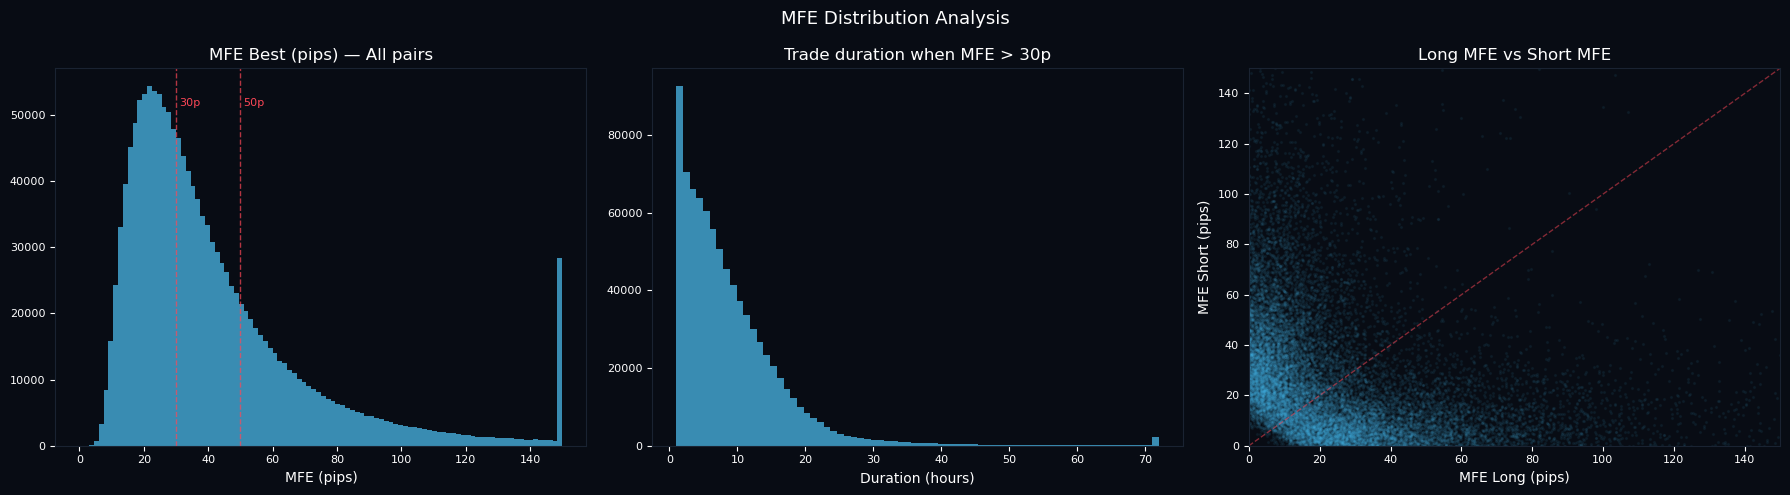

In [3]:
# MFE distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Histogram of MFE best
axes[0].hist(df_valid['mfe_best'].clip(upper=150), bins=100, color='#4fc3f7', alpha=0.7, edgecolor='none')
for thresh in [30, 50]:
    axes[0].axvline(thresh, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7)
    axes[0].text(thresh+1, axes[0].get_ylim()[1]*0.9, f'{thresh}p', color='#ff4757', fontsize=8)
axes[0].set_title('MFE Best (pips) — All pairs', color='white')
axes[0].set_xlabel('MFE (pips)', color='white')

# Duration distribution for MFE > 30
mask30 = df_valid['mfe_best'] > 30
dur_long = df_valid.loc[mask30 & (df_valid['best_dir'] == 'long'), 'trail_long_bars']
dur_short = df_valid.loc[mask30 & (df_valid['best_dir'] == 'short'), 'trail_short_bars']
dur_all = pd.concat([dur_long, dur_short])
axes[1].hist(dur_all.clip(upper=72), bins=72, color='#4fc3f7', alpha=0.7, edgecolor='none')
axes[1].set_title('Trade duration when MFE > 30p', color='white')
axes[1].set_xlabel('Duration (hours)', color='white')

# Long vs Short MFE scatter
sample = df_valid.sample(min(20000, len(df_valid)), random_state=42)
axes[2].scatter(sample['mfe_long_pips'], sample['mfe_short_pips'], alpha=0.05, s=2, color='#4fc3f7')
axes[2].plot([0, 150], [0, 150], '--', color='#ff4757', linewidth=1, alpha=0.5)
axes[2].set_xlim(0, 150); axes[2].set_ylim(0, 150)
axes[2].set_title('Long MFE vs Short MFE', color='white')
axes[2].set_xlabel('MFE Long (pips)', color='white')
axes[2].set_ylabel('MFE Short (pips)', color='white')

plt.suptitle('MFE Distribution Analysis', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Per-Pair Breakdown

In [4]:
# Per-pair MFE statistics
print(f'{"Pair":<10} {"Rows":>8} {"MFE>30p%":>10} {"MFE>50p%":>10} {"Avg MFE":>10} {"Med Trail":>10} {"Avg ATR24":>10}')
print('-' * 72)

pair_stats = {}
for pair in ALL_PAIRS:
    p = df_valid[df_valid['pair'] == pair]
    if len(p) == 0:
        continue
    pct_30 = 100 * (p['mfe_best'] > 30).mean()
    pct_50 = 100 * (p['mfe_best'] > 50).mean()
    avg_mfe = p['mfe_best'].mean()
    med_trail = p['trail_long_bars'].median()  # rough proxy
    avg_atr = p['mfe_atr_24'].mean()
    pair_stats[pair] = {'pct_30': pct_30, 'pct_50': pct_50, 'avg_mfe': avg_mfe}
    print(f'{pair:<10} {len(p):>8,} {pct_30:>9.1f}% {pct_50:>9.1f}% {avg_mfe:>9.1f} {med_trail:>9.0f}h {avg_atr:>9.1f}p')

Pair           Rows   MFE>30p%   MFE>50p%    Avg MFE  Med Trail  Avg ATR24
------------------------------------------------------------------------
EURUSD       98,250      49.6%      19.6%      36.3         4h      17.9p
GBPUSD       98,048      65.0%      28.5%      44.9         4h      22.5p
AUDUSD       98,459      46.2%      17.6%      35.3         4h      16.9p
NZDUSD       97,223      45.1%      17.0%      36.2         4h      16.6p
USDCAD       97,675      50.2%      20.5%      39.2         5h      18.2p
USDCHF       97,290      39.7%      14.0%      33.1         4h      16.5p
USDJPY       97,509      49.1%      21.4%      38.0         4h      17.8p
EURJPY       98,444      70.3%      35.6%      50.8         4h      24.6p
GBPJPY       98,236      85.9%      52.1%      63.5         4h      31.3p
EURGBP       98,224      27.0%       8.6%      28.5         4h      13.2p
EURAUD       98,149      81.1%      46.4%      60.7         4h      28.3p
AUDJPY       98,733      61.0%      28

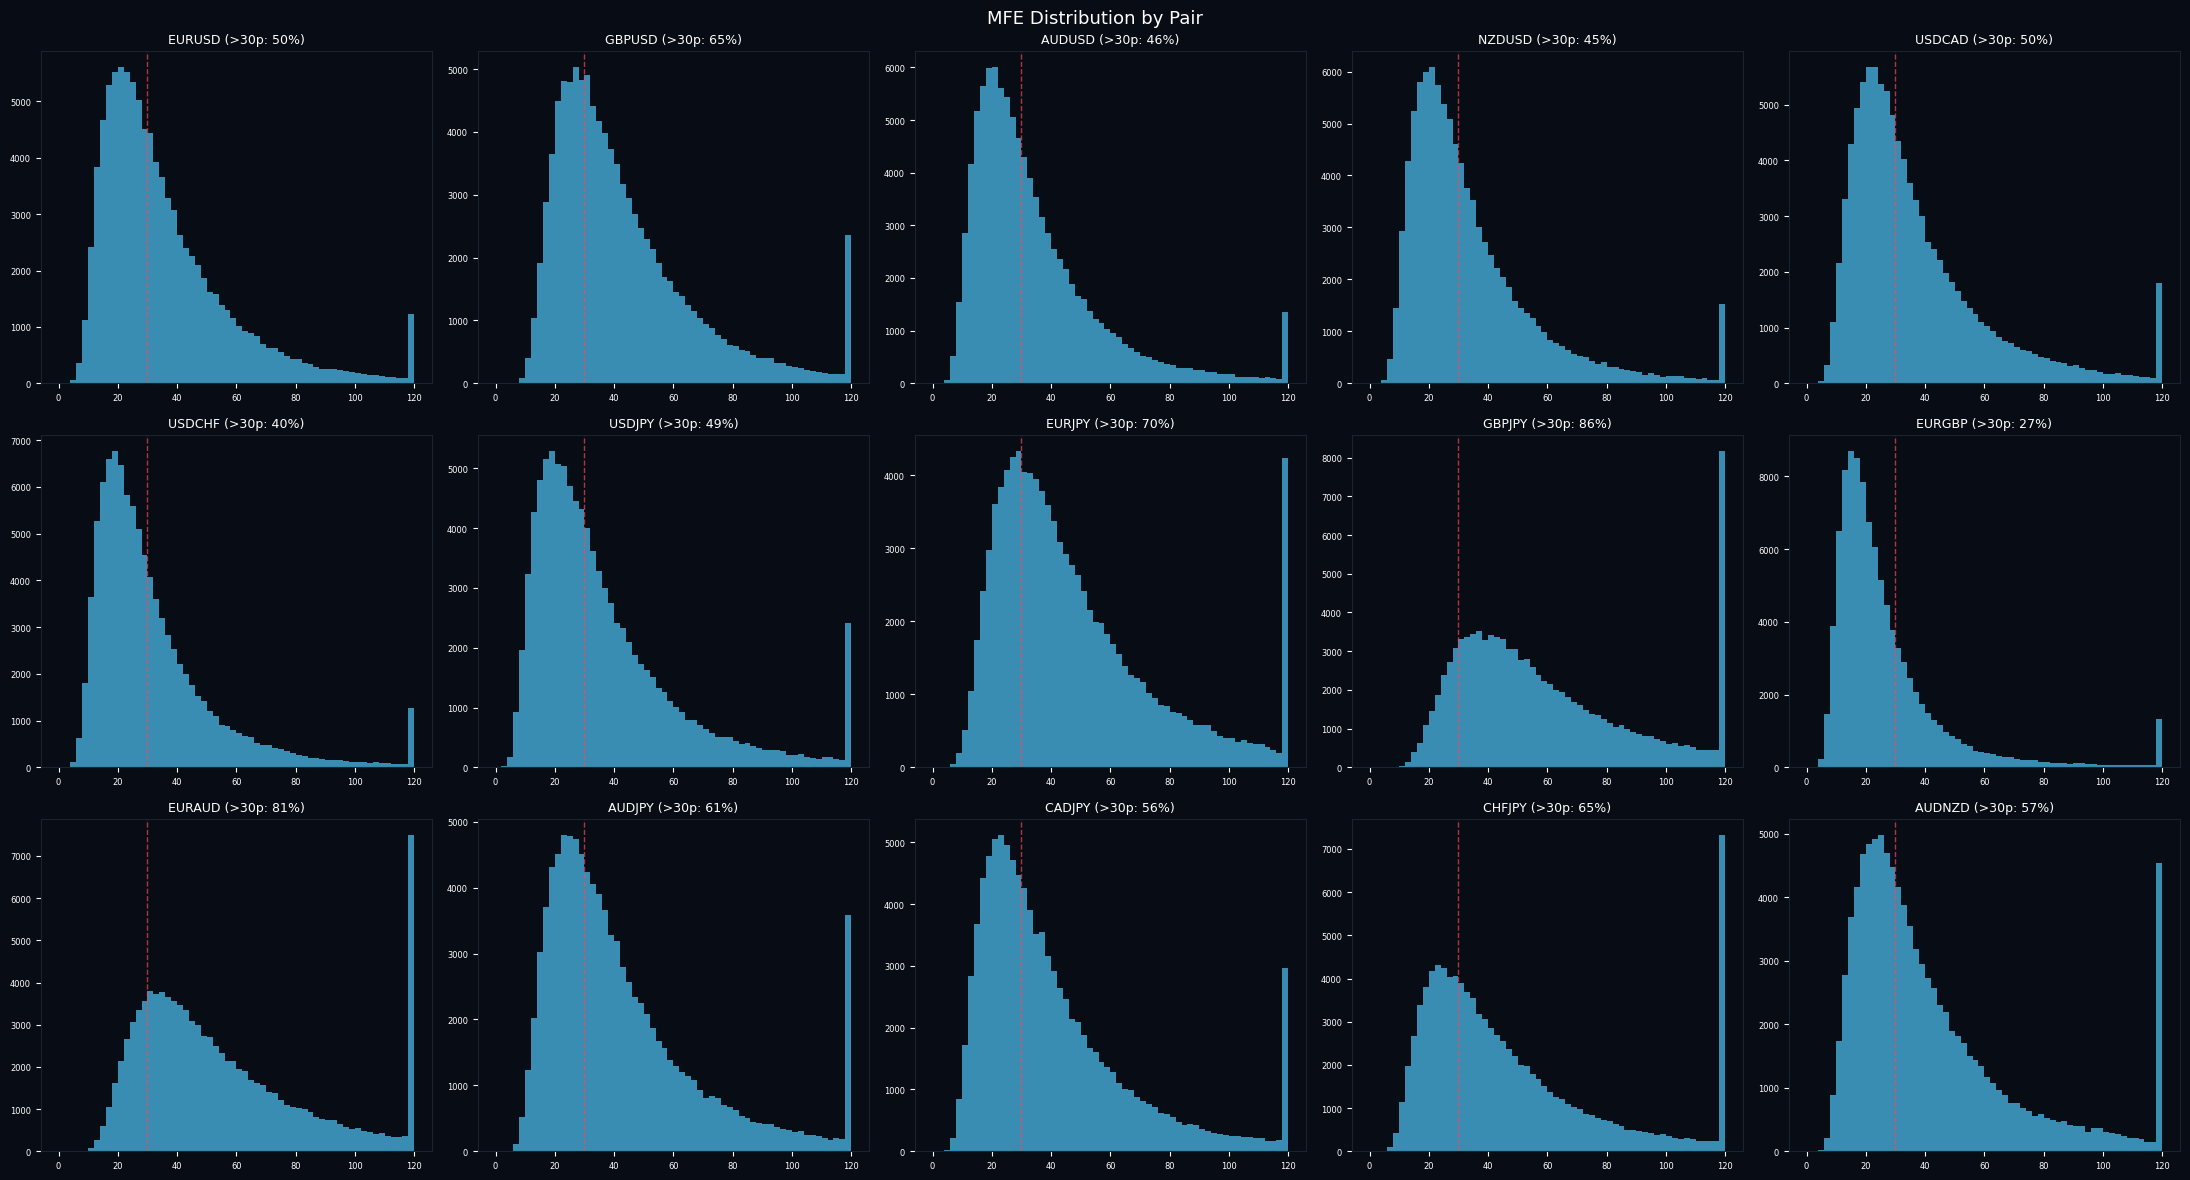

In [5]:
# Per-pair MFE distributions
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.patch.set_facecolor('#080c14')

for ax, pair in zip(axes.flat, ALL_PAIRS):
    ax.set_facecolor('#080c14')
    p = df_valid[df_valid['pair'] == pair]
    ax.hist(p['mfe_best'].clip(upper=120), bins=60, color='#4fc3f7', alpha=0.7, edgecolor='none')
    ax.axvline(30, color='#ff4757', linewidth=1, linestyle='--', alpha=0.7)
    pct = pair_stats[pair]['pct_30']
    ax.set_title(f'{pair} (>30p: {pct:.0f}%)', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=6)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('MFE Distribution by Pair', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 3. When Do Big Moves Happen? (Time Analysis)

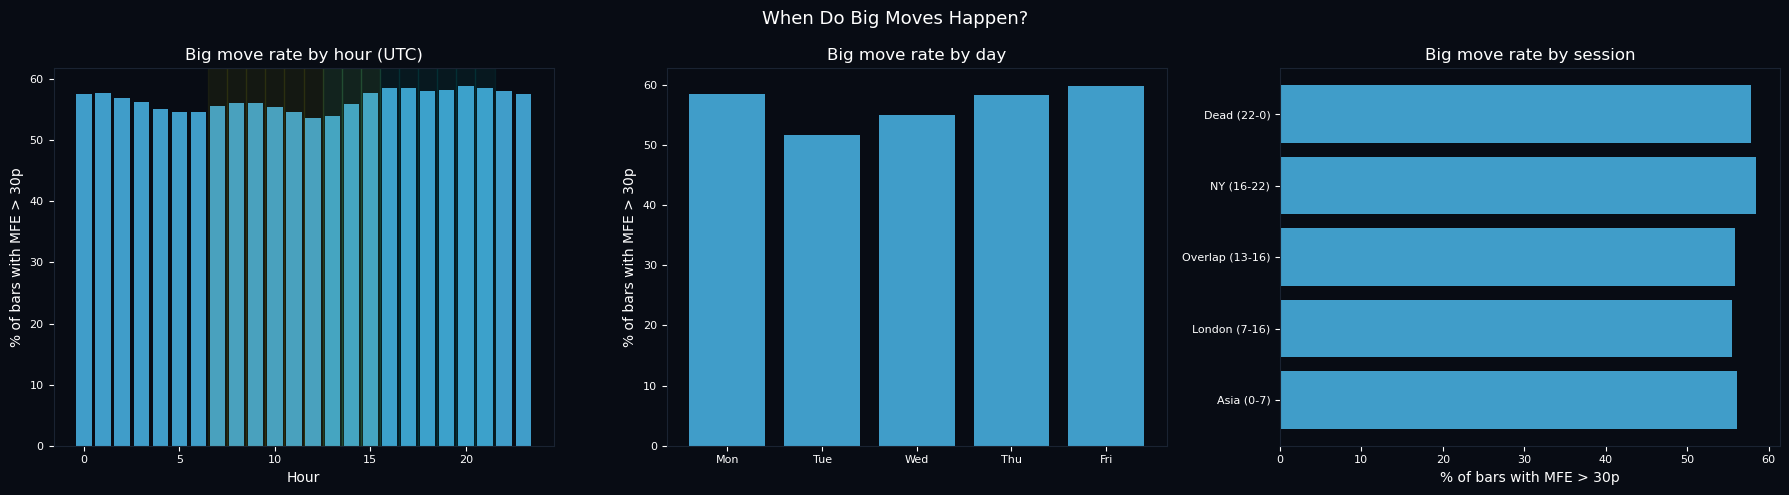

In [6]:
# Big move = MFE best > 30 pips (we'll calibrate this later)
df_valid['is_big'] = df_valid['mfe_best'] > 30
df_valid['hour'] = df_valid.index.hour
df_valid['dow'] = df_valid.index.dayofweek

# By hour of day
hourly_rate = df_valid.groupby('hour')['is_big'].mean() * 100

# By day of week
dow_rate = df_valid.groupby('dow')['is_big'].mean() * 100
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Hour of day
axes[0].bar(hourly_rate.index, hourly_rate.values, color='#4fc3f7', alpha=0.8)
axes[0].set_title('Big move rate by hour (UTC)', color='white')
axes[0].set_xlabel('Hour', color='white')
axes[0].set_ylabel('% of bars with MFE > 30p', color='white')
# Highlight sessions
for h in range(7, 16):
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.05, color='yellow')
for h in range(13, 22):
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.05, color='cyan')

# Day of week
axes[1].bar(range(5), dow_rate.values[:5], color='#4fc3f7', alpha=0.8)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(dow_labels, color='white')
axes[1].set_title('Big move rate by day', color='white')
axes[1].set_ylabel('% of bars with MFE > 30p', color='white')

# By session
session_rates = {
    'Asia (0-7)': df_valid[df_valid['hour'].between(0, 6)]['is_big'].mean() * 100,
    'London (7-16)': df_valid[df_valid['hour'].between(7, 15)]['is_big'].mean() * 100,
    'Overlap (13-16)': df_valid[df_valid['hour'].between(13, 15)]['is_big'].mean() * 100,
    'NY (16-22)': df_valid[df_valid['hour'].between(16, 21)]['is_big'].mean() * 100,
    'Dead (22-0)': df_valid[df_valid['hour'].isin([22, 23])]['is_big'].mean() * 100,
}
axes[2].barh(list(session_rates.keys()), list(session_rates.values()), color='#4fc3f7', alpha=0.8)
axes[2].set_title('Big move rate by session', color='white')
axes[2].set_xlabel('% of bars with MFE > 30p', color='white')

plt.suptitle('When Do Big Moves Happen?', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Feature Analysis — What Looks Different Before Big Moves?

Compare feature distributions for bars where MFE > 30p vs MFE < 15p.
This tells us which features have discriminating power.

In [7]:
# Split into big move vs no move
big = df_valid[df_valid['mfe_best'] > 30]
small = df_valid[df_valid['mfe_best'] < 15]

print(f'Big moves (MFE > 30p):  {len(big):,} bars')
print(f'Small moves (MFE < 15p): {len(small):,} bars')

# Compute separation score for each feature
# Using difference in means normalized by pooled std (Cohen's d)
separation = {}
for col in feature_cols:
    vals_big = big[col].dropna()
    vals_small = small[col].dropna()
    if len(vals_big) < 100 or len(vals_small) < 100:
        continue
    mean_diff = vals_big.mean() - vals_small.mean()
    pooled_std = np.sqrt((vals_big.std()**2 + vals_small.std()**2) / 2)
    if pooled_std > 1e-10:
        separation[col] = mean_diff / pooled_std

# Sort by absolute Cohen's d
sorted_sep = sorted(separation.items(), key=lambda x: abs(x[1]), reverse=True)

print(f'\nTop 30 features by Cohen\'s d (big vs small move):')
print(f'{"Feature":<35} {"Cohen d":>10} {"Direction"}')
print('-' * 60)
for col, d in sorted_sep[:30]:
    direction = 'higher before big move' if d > 0 else 'lower before big move'
    print(f'{col:<35} {d:>+10.3f} {direction}')

Big moves (MFE > 30p):  832,690 bars
Small moves (MFE < 15p): 125,259 bars

Top 30 features by Cohen's d (big vs small move):
Feature                                Cohen d Direction
------------------------------------------------------------
atr_72                                  +1.445 higher before big move
atr_24                                  +1.380 higher before big move
atr_6                                   +1.027 higher before big move
range_width_48                          +0.971 higher before big move
range_width_24                          +0.941 higher before big move
volume_cv                               -0.451 lower before big move
accel_std                               +0.425 higher before big move
jump_ratio_ma6                          -0.413 lower before big move
entropy_ma12                            +0.266 higher before big move
entropy_volume_divergence               +0.243 higher before big move
entropy_returns                         -0.217 lower befor

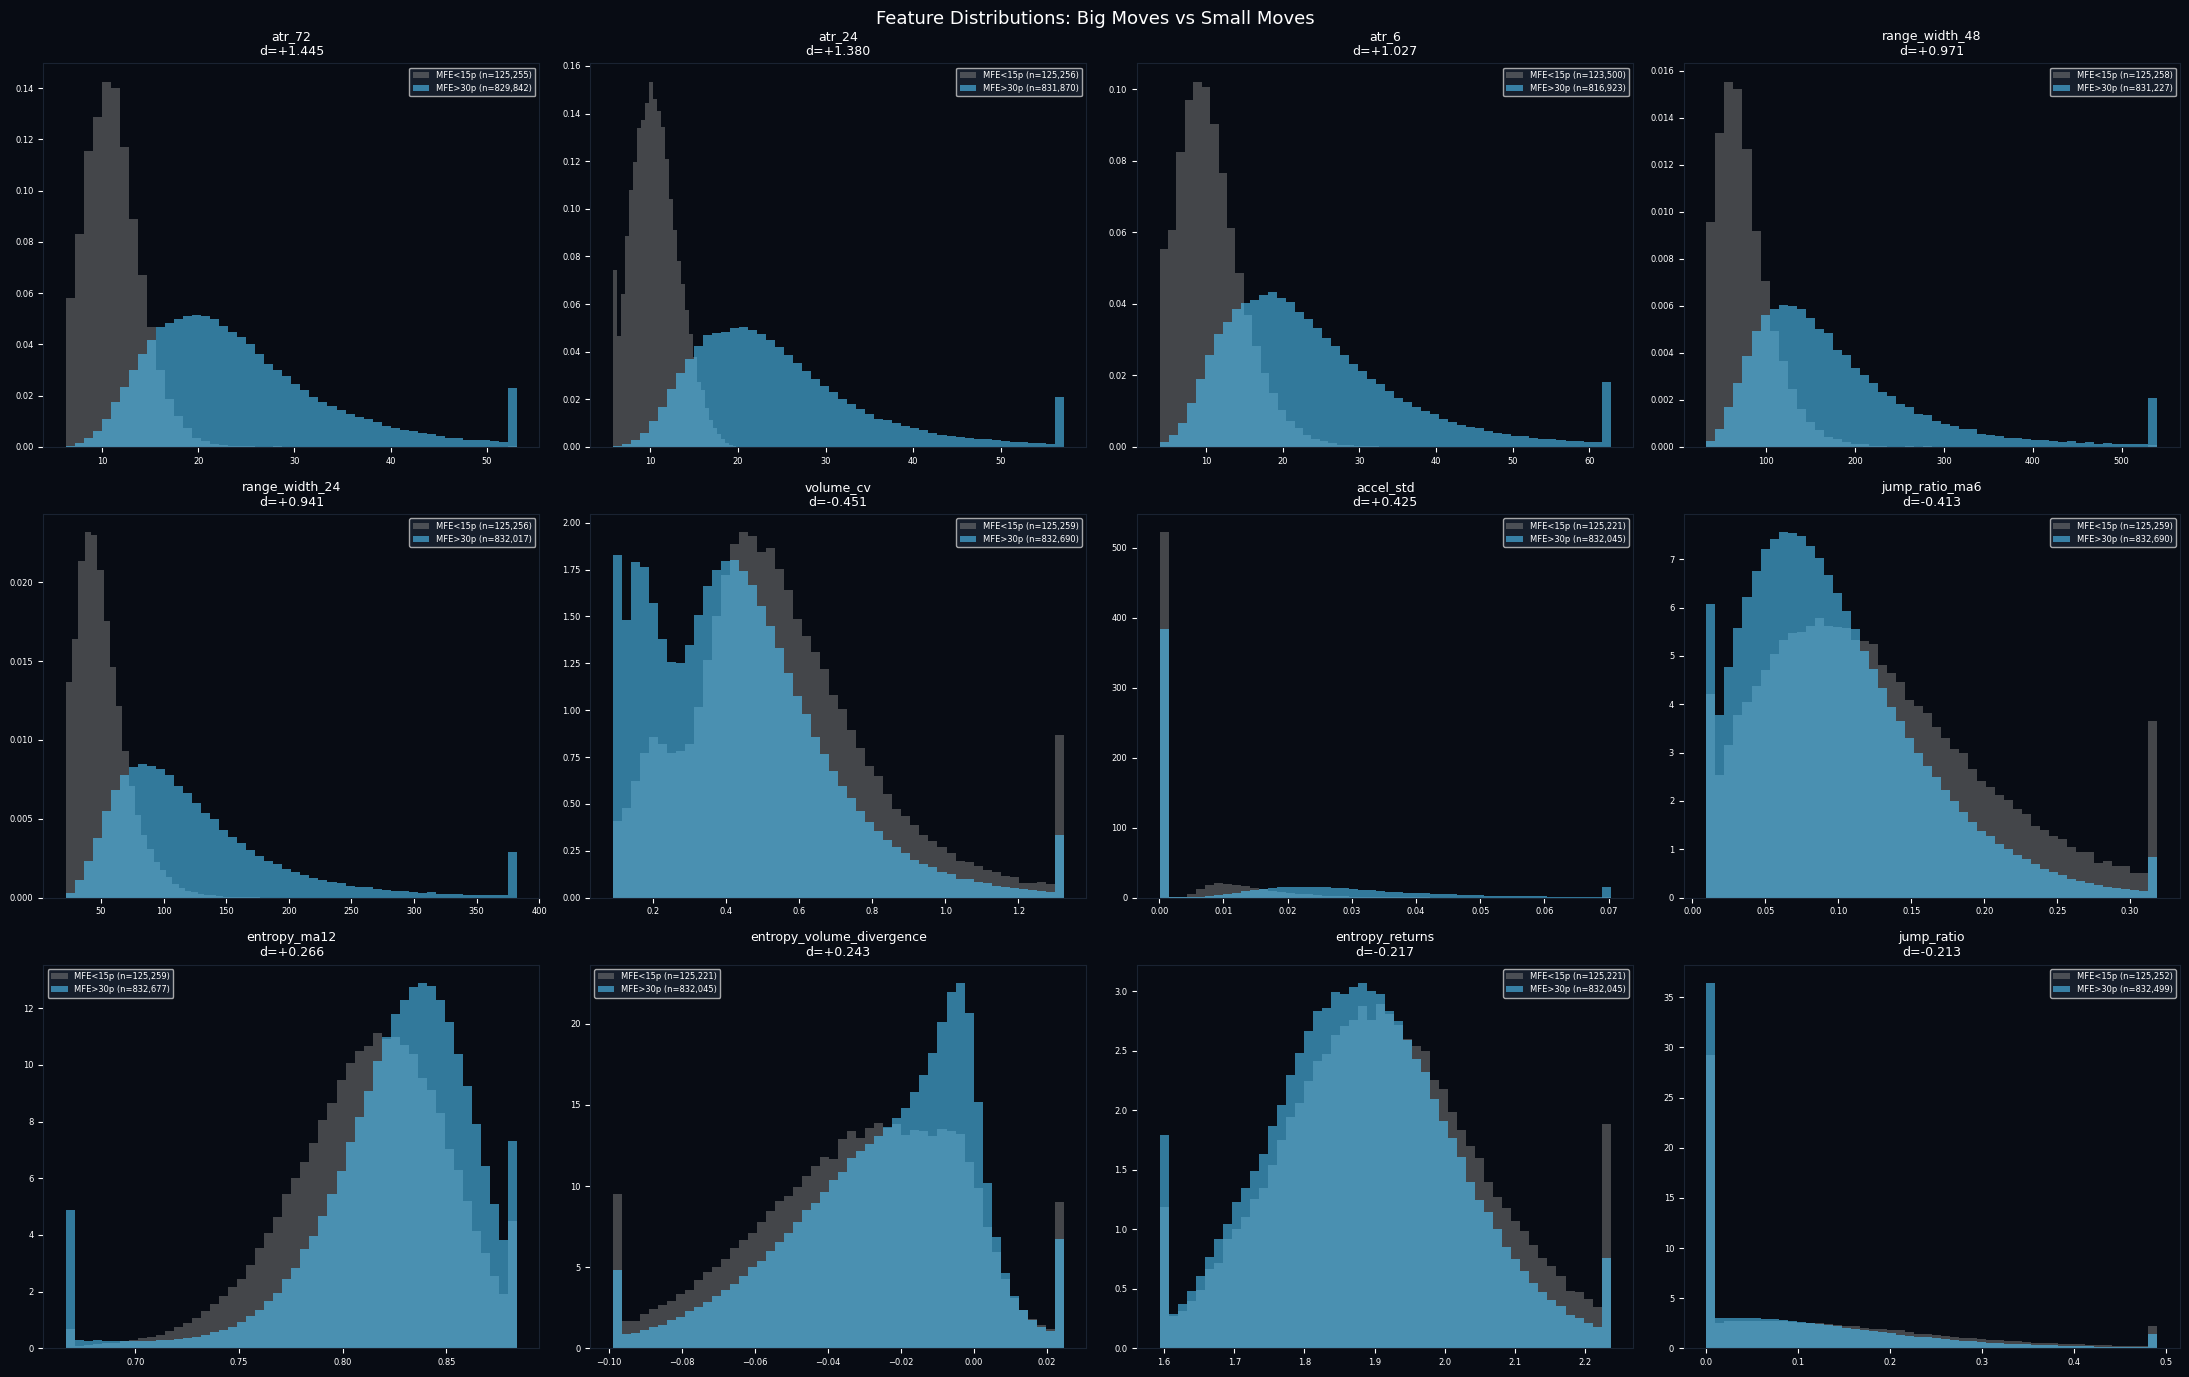

In [8]:
# Plot top 12 most discriminating features
top_features = [col for col, _ in sorted_sep[:12]]

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.patch.set_facecolor('#080c14')

for ax, col in zip(axes.flat, top_features):
    ax.set_facecolor('#080c14')
    
    vals_big = big[col].dropna()
    vals_small = small[col].dropna()
    
    # Clip outliers for visualization
    lo = min(vals_big.quantile(0.02), vals_small.quantile(0.02))
    hi = max(vals_big.quantile(0.98), vals_small.quantile(0.98))
    
    ax.hist(vals_small.clip(lo, hi), bins=50, alpha=0.5, color='gray', density=True, label=f'MFE<15p (n={len(vals_small):,})')
    ax.hist(vals_big.clip(lo, hi), bins=50, alpha=0.6, color='#4fc3f7', density=True, label=f'MFE>30p (n={len(vals_big):,})')
    
    d = separation[col]
    ax.set_title(f'{col}\nd={d:+.3f}', color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=6)
    ax.legend(fontsize=6, facecolor='#1a2332', labelcolor='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Distributions: Big Moves vs Small Moves', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

In [9]:
# Correlation of features with MFE best
corrs = {}
for col in feature_cols:
    valid = df_valid[[col, 'mfe_best']].dropna()
    if len(valid) > 1000:
        corrs[col] = valid[col].corr(valid['mfe_best'])

sorted_corrs = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)

print(f'Top 30 features correlated with MFE best:')
print(f'{"Feature":<35} {"Pearson r":>10}')
print('-' * 48)
for col, r in sorted_corrs[:30]:
    print(f'{col:<35} {r:>+10.4f}')

Top 30 features correlated with MFE best:
Feature                              Pearson r
------------------------------------------------
atr_24                                 +0.4355
atr_72                                 +0.3968
range_width_24                         +0.3651
atr_6                                  +0.3599
range_width_48                         +0.3413
accel_std                              +0.1570
jump_mean_size                         +0.1384
volume_cv                              -0.1205
amihud_illiq                           +0.0924
range_return_ratio                     -0.0902
rv                                     +0.0870
rv_close                               +0.0870
dist_from_24h_low                      +0.0812
kyle_lambda_r2                         -0.0807
entropy_volume_divergence              +0.0747
atr_ratio_6_72                         +0.0699
momentum_shift                         -0.0690
vpin_12h                               -0.0647
jump_ratio_ma6  

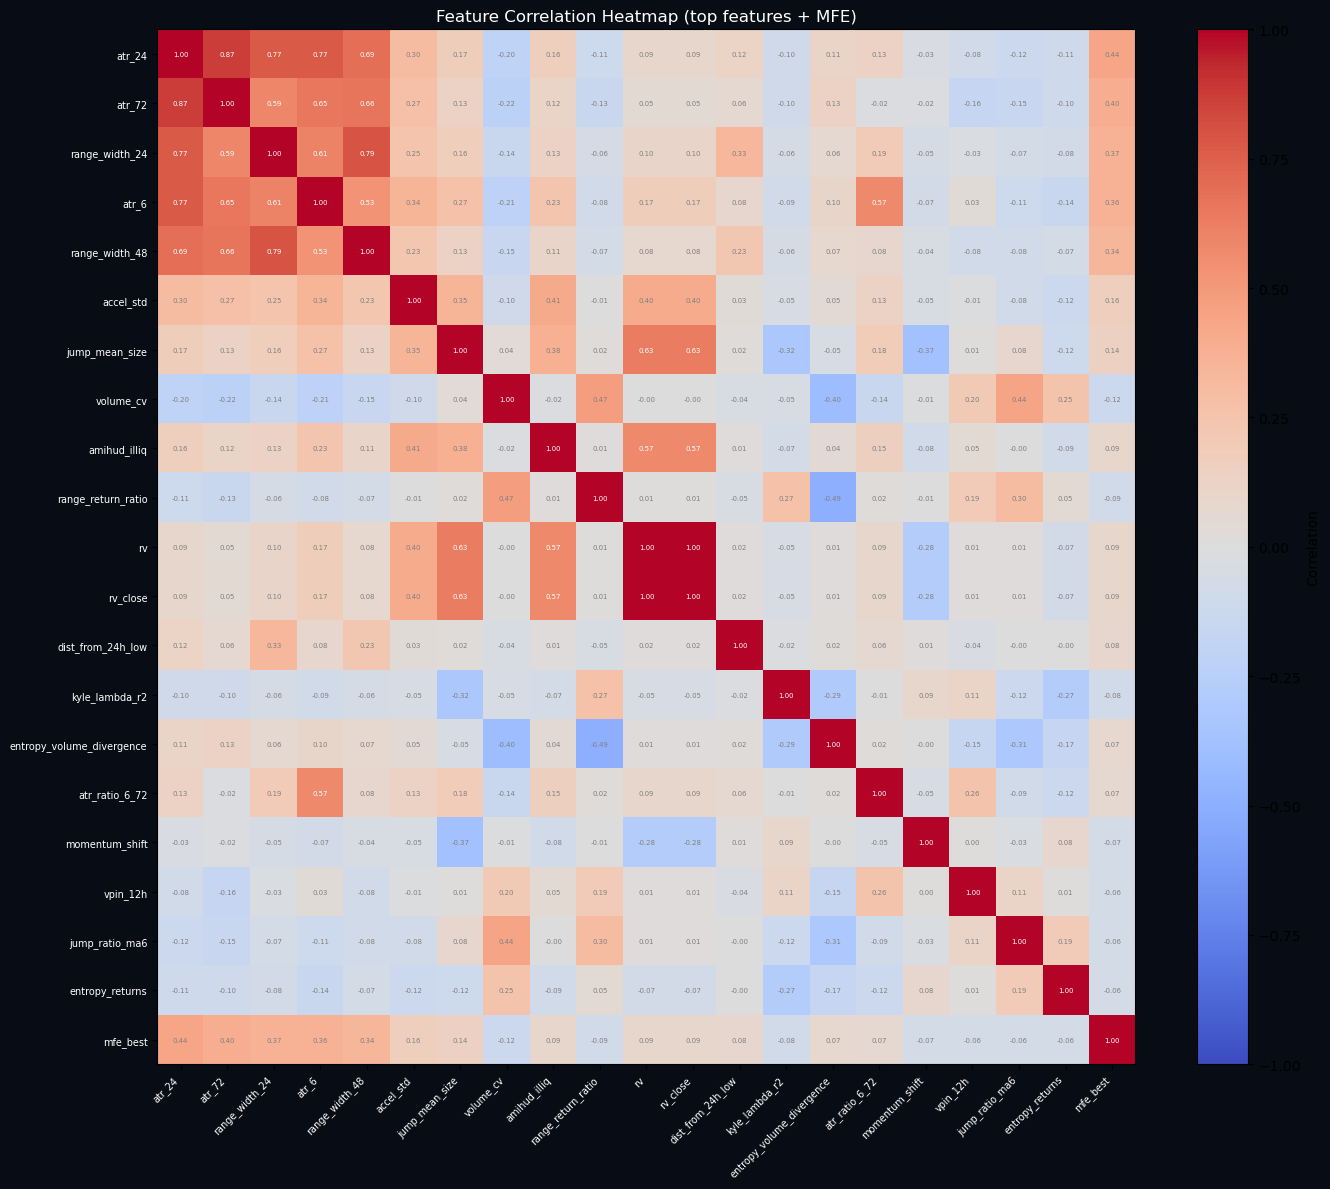

In [10]:
# Correlation heatmap of top features with MFE
top_corr_features = [col for col, _ in sorted_corrs[:20]]
cols_for_heatmap = top_corr_features + ['mfe_best']

corr_matrix = df_valid[cols_for_heatmap].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(cols_for_heatmap)))
ax.set_yticks(range(len(cols_for_heatmap)))
ax.set_xticklabels(cols_for_heatmap, rotation=45, ha='right', color='white', fontsize=7)
ax.set_yticklabels(cols_for_heatmap, color='white', fontsize=7)

# Add values
for i in range(len(cols_for_heatmap)):
    for j in range(len(cols_for_heatmap)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'gray'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=5, color=color)

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Feature Correlation Heatmap (top features + MFE)', color='white')
plt.tight_layout()
plt.show()

## 6. Target Threshold Selection

We need to decide the MFE threshold for binary classification.
Considerations:
- Too low (20p) → too many positives, noisy
- Too high (60p) → too few positives, hard to learn
- Should be economically meaningful after spread/slippage

In [11]:
# Analyze class balance at different thresholds
# Also compute the economic value: if we perfectly predicted every big move,
# what's the average reward (MFE) vs average risk (trailing stop)?

print(f'{"Threshold":>10} {"Positives":>10} {"Negatives":>10} {"Ratio":>8} {"Avg MFE":>10} {"Avg Trail":>10} {"Reward/Risk":>12}')
print('-' * 78)

for thresh in [15, 20, 25, 30, 35, 40, 50, 60]:
    pos = df_valid[df_valid['mfe_best'] > thresh]
    neg = df_valid[df_valid['mfe_best'] <= thresh]
    n_pos = len(pos)
    n_neg = len(neg)
    ratio = n_pos / max(n_neg, 1)
    avg_mfe = pos['mfe_best'].mean()
    avg_trail = pos['trail_stop_pips'].mean()
    rr = avg_mfe / avg_trail if avg_trail > 0 else 0
    print(f'{thresh:>8}p {n_pos:>10,} {n_neg:>10,} {ratio:>7.2f} {avg_mfe:>9.1f}p {avg_trail:>9.1f}p {rr:>11.2f}')

 Threshold  Positives  Negatives    Ratio    Avg MFE  Avg Trail  Reward/Risk
------------------------------------------------------------------------------
      15p  1,342,968    128,557   10.45      47.2p      32.6p        1.45
      20p  1,178,652    292,873    4.02      51.3p      34.3p        1.50
      25p    999,542    471,983    2.12      56.5p      36.2p        1.56
      30p    832,690    638,835    1.30      62.3p      38.1p        1.63
      35p    687,991    783,534    0.88      68.6p      40.1p        1.71
      40p    568,067    903,458    0.63      75.2p      41.9p        1.79
      50p    389,558  1,081,967    0.36      89.1p      45.6p        1.95
      60p    271,266  1,200,259    0.23     104.1p      49.2p        2.11


In [12]:
# Train vs test distribution check — ensure big moves aren't concentrated in one period
df_train_part = df_valid[df_valid.index <= TRAIN_END]
df_test_part = df_valid[df_valid.index > TRAIN_END]

print(f'Train period: {df_train_part.index.min().date()} to {df_train_part.index.max().date()} ({len(df_train_part):,} bars)')
print(f'Test period:  {df_test_part.index.min().date()} to {df_test_part.index.max().date()} ({len(df_test_part):,} bars)')

print(f'\n{"Threshold":>10} {"Train %":>10} {"Test %":>10} {"Stable?"}')
print('-' * 45)
for thresh in [20, 30, 40, 50]:
    train_pct = 100 * (df_train_part['mfe_best'] > thresh).mean()
    test_pct = 100 * (df_test_part['mfe_best'] > thresh).mean()
    diff = abs(train_pct - test_pct)
    stable = 'YES' if diff < 3 else 'DRIFT'
    print(f'{thresh:>8}p {train_pct:>9.1f}% {test_pct:>9.1f}% {stable:>8}')

Train period: 2009-09-25 to 2024-06-28 (1,335,153 bars)
Test period:  2024-07-01 to 2025-12-31 (136,372 bars)

 Threshold    Train %     Test % Stable?
---------------------------------------------
      20p      79.8%      83.5%    DRIFT
      30p      55.8%      64.0%    DRIFT
      40p      37.7%      47.6%    DRIFT
      50p      25.5%      35.6%    DRIFT


## 7. Autocorrelation of Big Moves — Do They Cluster?

If big moves cluster in time, that's useful — the model can learn "once a big move starts, more tend to follow."

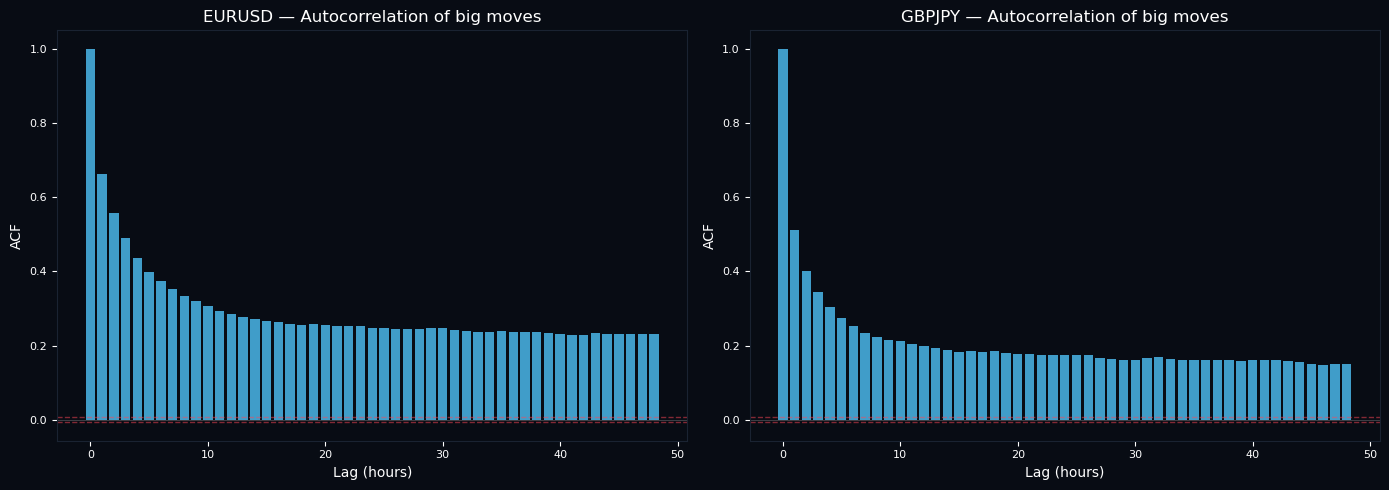

If bars above the red dashed line → big moves cluster (positive autocorrelation).


In [13]:
# Check if big moves cluster — autocorrelation of the binary signal
def manual_acf(x, nlags=48):
    """Compute autocorrelation function without statsmodels."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    var = np.sum(x**2) / n
    if var < 1e-20:
        return np.zeros(nlags + 1)
    acf_vals = np.array([1.0] + [np.sum(x[k:] * x[:-k]) / (n * var) for k in range(1, nlags + 1)])
    return acf_vals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Autocorrelation of is_big for a single pair
for pair_name, ax_idx in [('EURUSD', 0), ('GBPJPY', 1)]:
    pair_data = df_valid[df_valid['pair'] == pair_name].sort_index()
    if len(pair_data) < 500:
        continue
    acf_vals = manual_acf(pair_data['is_big'].values, nlags=48)
    axes[ax_idx].bar(range(len(acf_vals)), acf_vals, color='#4fc3f7', alpha=0.8)
    axes[ax_idx].axhline(0, color='white', linewidth=0.5, alpha=0.3)
    axes[ax_idx].axhline(1.96/np.sqrt(len(pair_data)), color='#ff4757', linewidth=1, linestyle='--', alpha=0.5)
    axes[ax_idx].axhline(-1.96/np.sqrt(len(pair_data)), color='#ff4757', linewidth=1, linestyle='--', alpha=0.5)
    axes[ax_idx].set_title(f'{pair_name} — Autocorrelation of big moves', color='white')
    axes[ax_idx].set_xlabel('Lag (hours)', color='white')
    axes[ax_idx].set_ylabel('ACF', color='white')

plt.tight_layout()
plt.show()

print('If bars above the red dashed line → big moves cluster (positive autocorrelation).')

## 8. Summary

In [14]:
print('=' * 60)
print('EXPLORATORY ANALYSIS — SUMMARY')
print('=' * 60)

n_total = len(df_valid)
n_30 = (df_valid['mfe_best'] > 30).sum()
n_50 = (df_valid['mfe_best'] > 50).sum()

print(f'\nDataset: {n_total:,} bars across {len(ALL_PAIRS)} pairs')
print(f'MFE > 30 pips: {n_30:,} ({100*n_30/n_total:.1f}%)')
print(f'MFE > 50 pips: {n_50:,} ({100*n_50/n_total:.1f}%)')
print(f'Avg trailing stop: {df_valid["trail_stop_pips"].mean():.1f} pips')
print(f'Avg trade duration: {df_valid["trail_long_bars"].mean():.1f} hours')

print(f'\nTop 10 discriminating features (Cohen d):')
for col, d in sorted_sep[:10]:
    print(f'  {col:<35} d={d:+.3f}')

print(f'\nTop 10 correlated features (Pearson r):')
for col, r in sorted_corrs[:10]:
    print(f'  {col:<35} r={r:+.4f}')

print(f'\nRecommendation for notebook 03:')
print(f'  Target: binary classification (MFE best > threshold)')
print(f'  Threshold candidates: 30p (balanced) or 40p (higher quality)')
print(f'  Features: all {len(feature_cols)} features')
print(f'  Train/test split: {TRAIN_END}')

EXPLORATORY ANALYSIS — SUMMARY

Dataset: 1,471,525 bars across 15 pairs
MFE > 30 pips: 832,690 (56.6%)
MFE > 50 pips: 389,558 (26.5%)
Avg trailing stop: 31.1 pips
Avg trade duration: 6.2 hours

Top 10 discriminating features (Cohen d):
  atr_72                              d=+1.445
  atr_24                              d=+1.380
  atr_6                               d=+1.027
  range_width_48                      d=+0.971
  range_width_24                      d=+0.941
  volume_cv                           d=-0.451
  accel_std                           d=+0.425
  jump_ratio_ma6                      d=-0.413
  entropy_ma12                        d=+0.266
  entropy_volume_divergence           d=+0.243

Top 10 correlated features (Pearson r):
  atr_24                              r=+0.4355
  atr_72                              r=+0.3968
  range_width_24                      r=+0.3651
  atr_6                               r=+0.3599
  range_width_48                      r=+0.3413
  accel_std  